In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import matplotlib.pyplot as plt
import mudata
import celldega as dega
import scanpy as sc
import pandas as pd
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, Polygon
import warnings
warnings.filterwarnings("ignore")



env: ANYWIDGET_HMR=1


In [2]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
tech = 'Xenium'
DATA_DIR = f'data/raw'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'data/landscape_files/{dataset_name}'

# Load h5ad file
adata = sc.read_h5ad(f'{data_dir}.h5ad')
adata.obs.set_index('cell_id', inplace=True)

gdf_trx = dega.nbhd._get_gdf_trx(data_dir)
gdf_cell = dega.nbhd._get_gdf_cell(adata)
df_cell = dega.nbhd._get_df_cell(adata)


# Create gdf for all types of nbhd

In [4]:
# ALPHA
alphas_list = range(30, 60, 5)
gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
gdf_alpha_select = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

# Hex
gdf_hex = dega.nbhd.generate_hex_grid(gdf_cell, radius=50)

# SKTCH
gdf_micron = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
gdf_micron['name'] = gdf_micron['roi']

# GRAD
gdf_roi = gdf_micron.loc[gdf_micron['roi'] == 'region_1']
gdf_bands = dega.nbhd.calc_grad_nbhd_from_roi(gdf_roi, gdf_cell, 200)
gdf_bands['name'] = gdf_bands['band']

nbhd_lookup = {
    'ALPH': gdf_alpha_select,
    'HEX': gdf_hex,
    'SKTCH': gdf_micron,
    'GRAD': gdf_bands,
}


In [20]:
nbhd_type = 'HEX'  # Choose from 'ALPH', 'HEX', 'SKTCH', 'GRAD'
gdf_nbhd = nbhd_lookup[nbhd_type]

# Create NBHD instance and attached derived matrices

In [21]:
# Create NBHD instance
nbhd = dega.nbhd.NBHD(gdf_nbhd, nbhd_type=nbhd_type, source='X cells', name='X cell alpha shapes')

# Calculate derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbg_cd = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'CD', 'name')
nbg_lcd_dict = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'LCD', 'name')
nbg_cf= dega.nbhd.calc_nbg_cf(data_dir, gdf_nbhd, unique_nbhd_col='name')

# Attach derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbhd.set_derived('NBG-CD', nbg_cd)
nbhd.set_derived('NBG-CF', nbg_cf)
for cluster in nbg_lcd_dict.keys():
    if cluster != 'all':
        nbhd.set_derived('NBG-LCD', nbg_lcd_dict[cluster], subkey=cluster)

# Calculate and attachcderived NBP (both abs and pct)
df_nbp, df_nbp_pct = dega.nbhd.calc_nbp(gdf_cell, nbhd_lookup[nbhd_type])
nbhd.set_derived('NBP', df_nbp, subkey='abs')
nbhd.set_derived('NBP', df_nbp_pct, subkey='pct')

# Calculate and attachcderived NBM (metadata)
unique_nbhd_col = 'name'
df_meta = dega.nbhd.get_nbhd_meta(gdf_nbhd, unique_nbhd_col, gdf_trx, gdf_cell)
nbhd.set_derived('NBM', df_meta)


# Retrieve data and plot

### NBG

NBG-CD data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0.000000,0.0,0.0,1.352402,0.000000,0.0000,0.084977,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.636131,0.0,0.000000,0.258784
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",0.031594,0.0,0.0,0.216463,0.312521,0.0225,0.077016,0.010964,...,0.022742,0.055474,0.0,0.266640,0.0,0.0,0.752364,0.0,0.152725,0.000000
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0.000000,0.0,0.0,0.000000,0.510874,0.0000,0.000000,0.000000,...,0.042488,0.000000,0.0,0.151858,0.0,0.0,0.318016,0.0,0.000000,0.000000


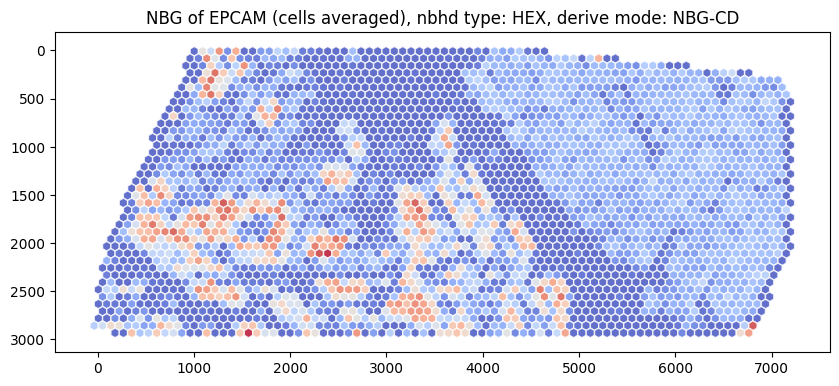

NBG-LCD data example, cluster:1


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


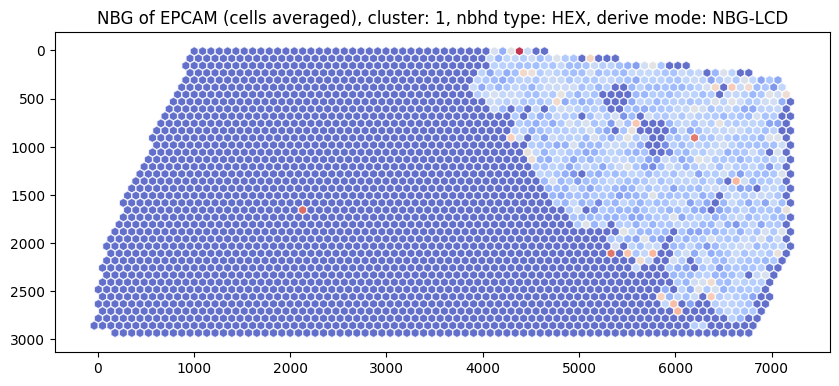

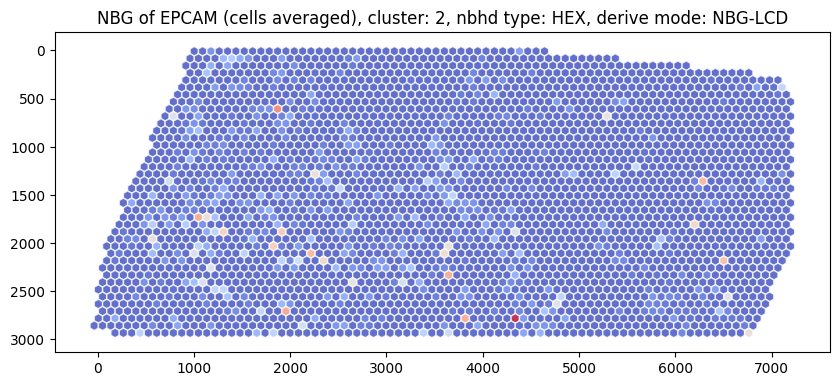

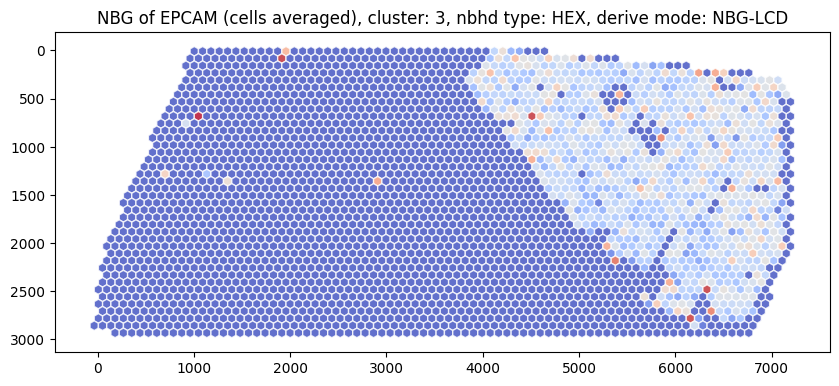

NBG-CF data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,UnassignedCodeword_0494,UnassignedCodeword_0495,UnassignedCodeword_0496,UnassignedCodeword_0497,UnassignedCodeword_0498,UnassignedCodeword_0499,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 33.96586, 1004.48824 58.9...",0.0,0.0,0.0,22.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,10.0
1,hex_1,"POLYGON ((1134.39205 33.96586, 1091.09078 58.9...",1.0,0.0,0.0,23.0,41.0,2.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,59.0,1.0,10.0,0.0
2,hex_2,"POLYGON ((1220.99459 33.96586, 1177.69332 58.9...",0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,1.0,0.0,1.0


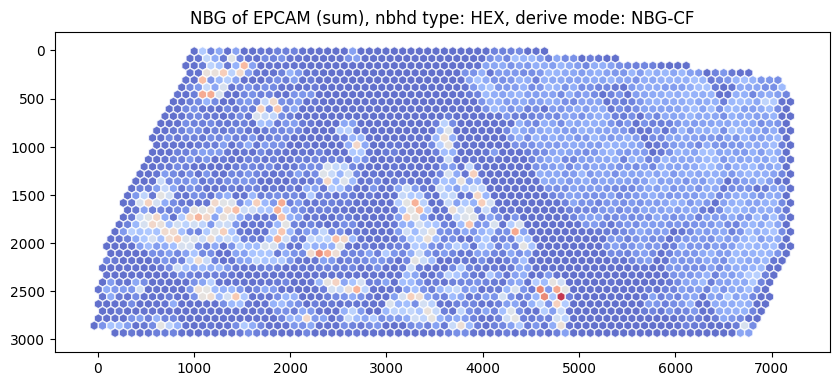

In [22]:
gene = 'EPCAM'

# Retrieve and visualize
gdf_nbg_cd = nbhd.get_derived('NBG-CD')
print ('NBG-CD data example')
display(gdf_nbg_cd.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (cells averaged), nbhd type: {nbhd_type}, derive mode: NBG-CD')
ax.invert_yaxis()
plt.show()

# Retrieve and visualize
clusters = ['1','2','3']
for cluster in clusters:
    gdf_nbg_lcd = nbhd.get_derived('NBG-LCD', cluster)

    if cluster == '1':
        print (f'NBG-LCD data example, cluster:{cluster}')
        display(gdf_nbg_lcd.head(3))       

    fig, ax = plt.subplots(figsize=(10, 5))                           
    gdf_nbg_lcd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'NBG of {gene} (cells averaged), cluster: {cluster}, nbhd type: {nbhd_type}, derive mode: NBG-LCD')       
    ax.invert_yaxis()
    plt.show()


# Retrieve and visualize
gdf_nbg_cf = nbhd.get_derived('NBG-CF')

print ('NBG-CF data example')
display(gdf_nbg_cf.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cf.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (sum), nbhd type: {nbhd_type}, derive mode: NBG-CF')
ax.invert_yaxis()
plt.show()


### NBP

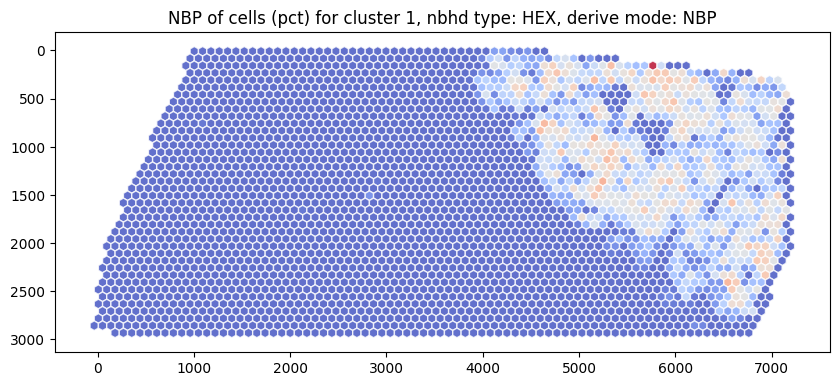

In [23]:
# Retrieve and visualize
sub_key = 'pct'
cluster_name = '1'

gdf_nbp = nbhd.get_derived('NBP', sub_key)

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbp.plot(cluster_name, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBP of cells ({sub_key}) for cluster {cluster_name}, nbhd type: {nbhd_type}, derive mode: NBP')
ax.invert_yaxis()
plt.show()

### NBM (metadata)

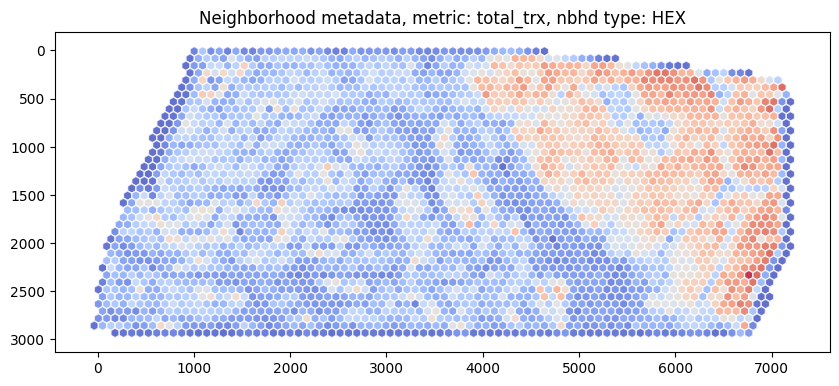

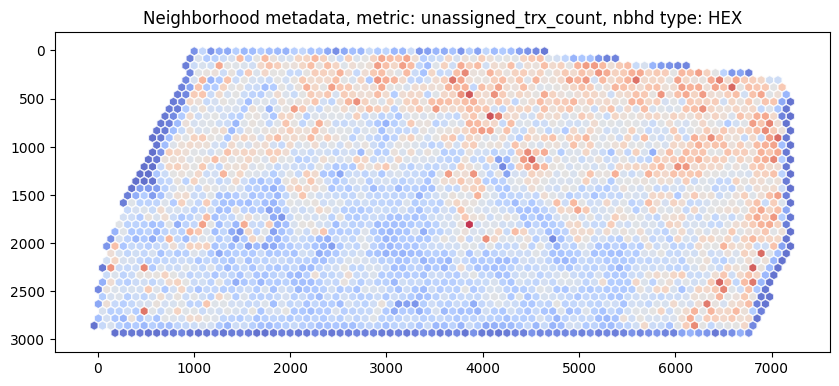

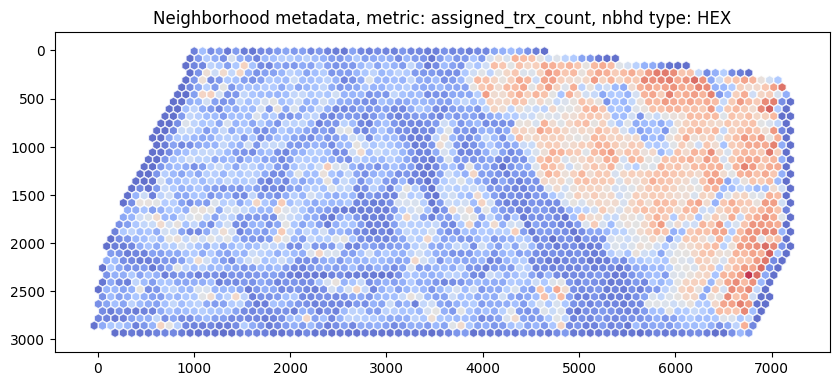

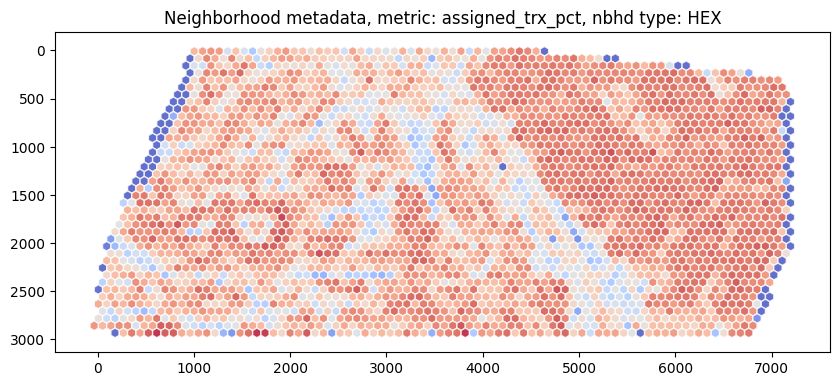

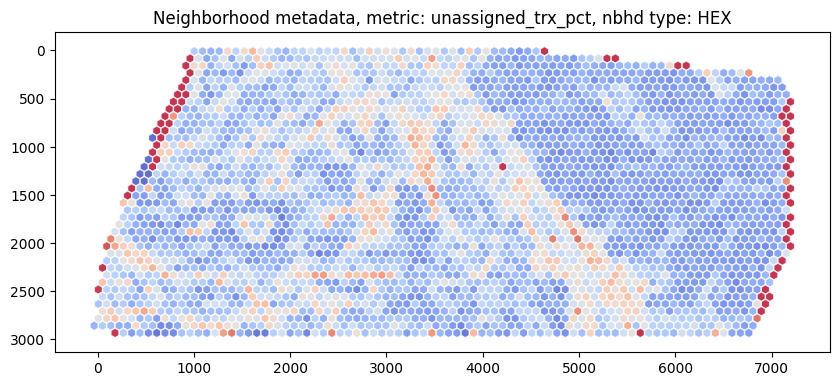

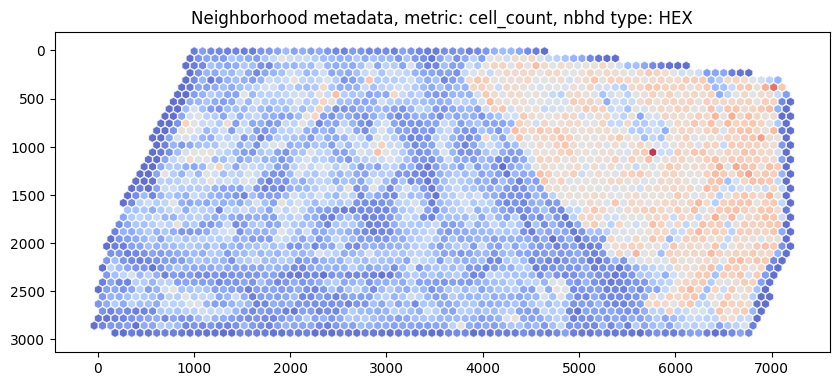

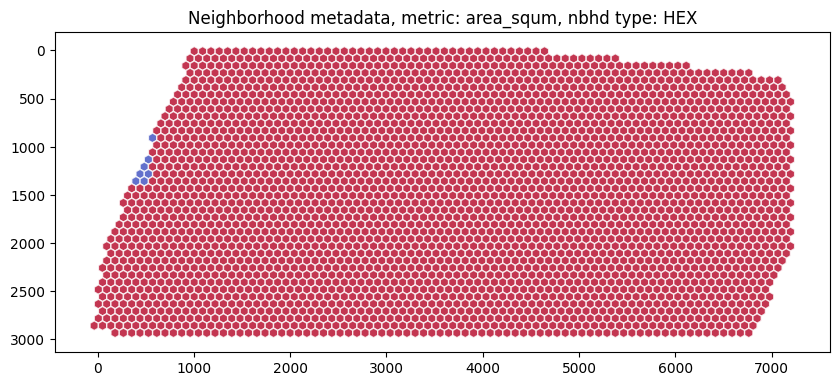

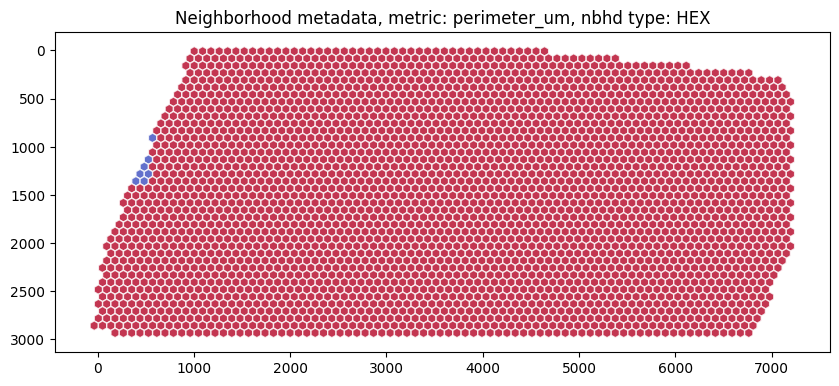

In [24]:
meta = nbhd.get_derived('NBM', df_meta)

for metric in meta.select_dtypes(include='number').columns:
    fig, ax = plt.subplots(figsize=(10, 5))                           
    meta.plot(metric, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood metadata, metric: {metric}, nbhd type: {nbhd_type}')
    ax.invert_yaxis()
    plt.show()

In [25]:
nbhd.summary()

{'name': 'X cell alpha shapes',
 'type': 'HEX',
 'n_regions': 3065,
 'derived': {'NBI': None,
  'NBG-CF': (3058, 541),
  'NBG-CD': (3065, 377),
  'NBG-LCD': {'4': (3065, 377),
   '2': (3065, 377),
   '0': (3065, 377),
   '7': (3065, 377),
   '3': (3065, 377),
   '9': (3065, 377),
   '8': (3065, 377),
   '6': (3065, 377),
   '5': (3065, 377),
   '1': (3065, 377),
   '10': (3065, 377)},
  'NBP': {'abs': (2987, 11), 'pct': (2987, 11)},
  'NBN-O': None,
  'NBN-B': None,
  'NBM': (3058, 8)},
 'meta': {}}

# Neighborhood by neighborhood

ALPH
calculating neighborhood overlap
(49, 4)


,nbhd_1,nbhd_2,overlap_area,geometry
0,0_35,2_35,4679966.74,"MULTIPOLYGON (((313.206 2859.320, 323.670 2863..."
1,0_35,1_35,34152.73,"MULTIPOLYGON (((6632.260 2752.140, 6628.363 27..."
2,0_35,3_35,86889.75,"MULTIPOLYGON (((6696.800 2740.560, 6691.240 27..."
3,0_35,5_35,297301.74,"MULTIPOLYGON (((6716.072 2741.804, 6702.230 27..."
4,0_35,6_35,27883.91,"MULTIPOLYGON (((6435.489 2778.942, 6458.940 27..."


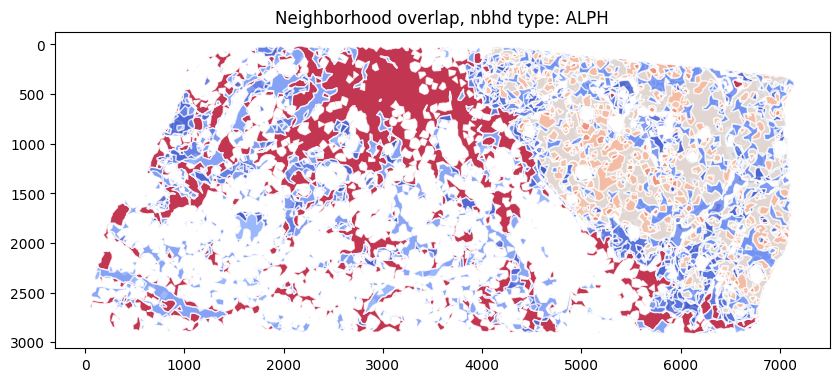

pivoted matrix


,0_35,10_35,1_35,2_35,3_35,4_35,5_35,6_35,7_35,8_35,9_35
0_35,NaN,12425.00,34152.73,4679966.74,86889.75,764157.63,297301.74,27883.91,637836.70,1026608.62,39657.38
10_35,12425.00,0.00,935449.19,31810.22,907615.12,0.00,755690.86,769024.86,58210.66,13642.15,3421.13
1_35,34152.73,935449.19,0.00,95054.43,3843267.53,0.00,2943534.21,3196554.21,283395.54,19837.35,34487.28
2_35,4679966.74,31810.22,95054.43,0.00,163217.27,240085.50,601852.44,107987.58,592361.43,1054802.86,19616.26
3_35,86889.75,907615.12,3843267.53,163217.27,0.00,0.00,2876013.72,2976043.83,448579.30,39194.98,52438.54
4_35,764157.63,0.00,0.00,240085.50,0.00,0.00,0.00,0.00,10221.88,27540.88,0.00
5_35,297301.74,755690.86,2943534.21,601852.44,2876013.72,0.00,0.00,2351732.16,423409.85,138812.96,34036.30
6_35,27883.91,769024.86,3196554.21,107987.58,2976043.83,0.00,2351732.16,0.00,192429.44,24778.17,17595.19
7_35,637836.70,58210.66,283395.54,592361.43,448579.30,10221.88,423409.85,192429.44,0.00,206143.71,12580.99
8_35,1026608.62,13642.15,19837.35,1054802.86,39194.98,27540.88,138812.96,24778.17,206143.71,0.00,14818.21


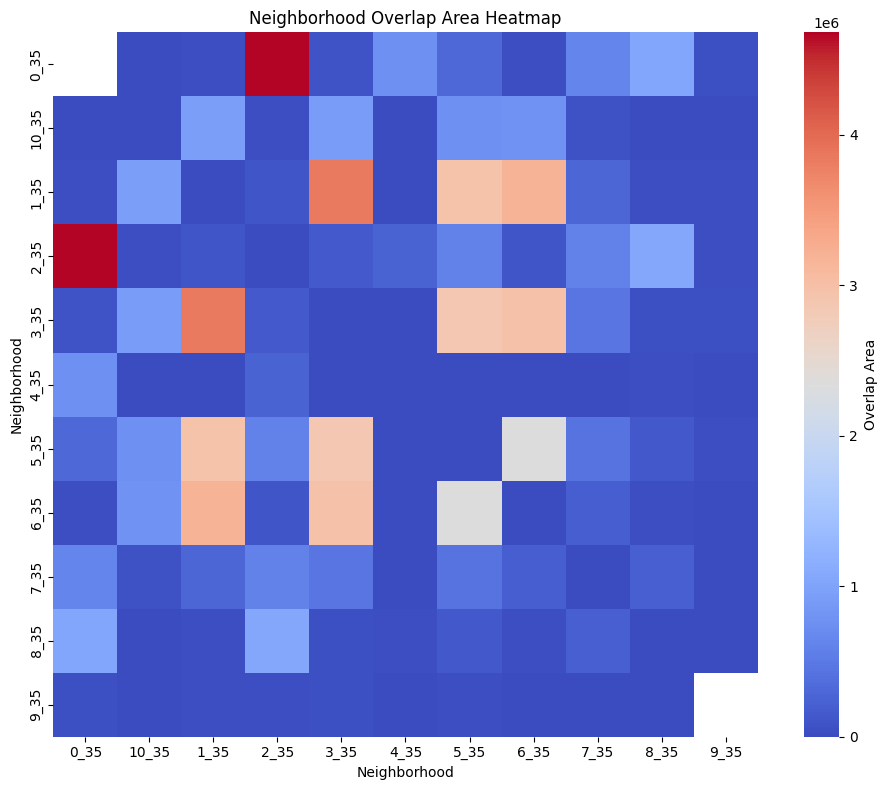

HEX
calculating neighborhood bordering
(5285, 2)


,nbhd_1,nbhd_2
0,hex_0,hex_1
1,hex_0,hex_44
2,hex_1,hex_2
3,hex_3,hex_4
4,hex_4,hex_5


SKTCH
calculating neighborhood bordering
(0, 2)


,nbhd_1,nbhd_2


GRAD
calculating neighborhood bordering
(28, 2)


,nbhd_1,nbhd_2
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


In [26]:

for nbhd_type in ['ALPH', 'HEX', 'SKTCH', 'GRAD']:
    print (nbhd_type)
    gdf_nbhd = nbhd_lookup[nbhd_type]
    nb = gdf_nbhd[['name','geometry']]


    if nbhd_type == 'ALPH':
        print ('calculating neighborhood overlap')
        df_nn = dega.nbhd.calc_nb_overlap(nb)
        print (df_nn.shape)
        display(df_nn.head(5))

        if len(df_nn) > 0:
            fig, ax = plt.subplots(figsize=(10, 5))                           
            df_nn.plot('overlap_area', ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
            ax.set_title(f'Neighborhood overlap, nbhd type: {nbhd_type}')
            ax.invert_yaxis()
            plt.show()

            # Step 1: Pivot the data into a matrix
            df_matrix = df_nn.pivot(index="nbhd_1", columns="nbhd_2", values="overlap_area")

            # Step 2: Fill NaNs with 0 (no overlap) and make symmetric (optional but cleaner)
            df_matrix = df_matrix.fillna(0)
            df_matrix = df_matrix.add(df_matrix.T, fill_value=0)  # Symmetrize

            print ('pivoted matrix')
            display(df_matrix)

            # Step 3: Plot heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(df_matrix, cmap="coolwarm", annot=False, square=True, cbar_kws={'label': 'Overlap Area'})
            plt.title("Neighborhood Overlap Area Heatmap")
            plt.xlabel("Neighborhood")
            plt.ylabel("Neighborhood")
            plt.tight_layout()
            plt.show()
    else:
        print ('calculating neighborhood bordering')
        df_nn = dega.nbhd.calc_nb_bordering(nb)
        print (df_nn.shape)
        display(df_nn.head(5))


# NBI (nbhd by image)

# Mudata testing

In [19]:
# # Testing
# munbhd = MuData({
#     "nbg": AnnData(X=nbg_mat, obs=gdf, var=genes...),   # gene expression
#     "nbp": AnnData(X=nbp_mat, obs=gdf, var=pop ...),    # population proportions
#     "nbi": AnnData(X=nbi_mat, obs=gdf, var=images ...), # image intensities
#     "nbn": AnnData(X=nbn_mat, obs=gdf, var=gdf ...),    # spatial interaction matrix
# })


# mdata.write(f"{path_landscape_files}/nhbd_collections.h5mu")  

# import muon as mu

# # Load the h5mu file
# mdata = mu.read(f"{path_landscape_files}/nhbd_collections.h5mu")

In [ ]:
from rasterio import features
import numpy as np


def calc_img_zonal_stats(gdf, img_array, channel_names=None):
    """
    Calculate mean intensity for each polygon in gdf over each channel in img_array.

    Parameters:
        gdf (GeoDataFrame): GeoDataFrame with 'geometry' column (polygons).
        img_array (np.ndarray): Image array of shape (channels, height, width) or (height, width, channels).
        channel_names (dict, optional): Mapping {channel_index: channel_name}. If None, use default names.

    Returns:
        DataFrame: mean intensity per polygon per channel, indexed by gdf index.
    """
    if img_array.ndim == 2:
        img_array = img_array[np.newaxis, ...]
    elif img_array.shape[0] < 10 and img_array.shape[-1] > 10:
        img_array = np.moveaxis(img_array, -1, 0)

    height, width = img_array.shape[1], img_array.shape[2]
    transform = (1, 0, 0, 0, 1, 0)  # identity (pixel coordinates)

    means = []
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom.is_empty:
            means.append([np.nan] * img_array.shape[0])
            continue
        mask = features.geometry_mask([geom], out_shape=(height, width), transform=transform, invert=True)
        mean_vals = [np.nanmean(img_array[c][mask]) for c in range(img_array.shape[0])]
        means.append(mean_vals)

    if channel_names is not None:
        columns = [channel_names.get(i, f'channel_{i}') for i in range(img_array.shape[0])]
    else:
        columns = [f'channel_{i}' for i in range(img_array.shape[0])]
    df_means = pd.DataFrame(means, columns=columns, index=gdf.index)
    return df_means
